# Diamonds - Predicción de Precio
## Modelo de Regresión

## Descripción de columnas del dataset

- **carat**: peso del diamante en quilates (1 quilate = 0.2 gramos). A mayor peso, mayor precio.
- **cut**: calidad del corte. Escala: Fair < Good < Very Good < Premium < Ideal (mejor).
- **color**: color del diamante. Escala: J (peor, con tinte amarillo) → D (mejor, incoloro).
- **clarity**: claridad/pureza, qué tan visibles son las imperfecciones internas. Escala: I1 (peor) → IF (mejor, sin imperfecciones).
- **depth**: porcentaje de profundidad total = z / promedio(x, y) * 100.
- **table**: ancho de la cara superior plana del diamante, como porcentaje de su diámetro promedio.
- **price**: precio en dólares (variable objetivo a predecir).
- **x**: largo en mm.
- **y**: ancho en mm.
- **z**: profundidad/alto en mm.

## Paso 1 - Carga de datos

In [1]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/MarcosUriel123/datasets/main/diamonds.csv')

cols_id = [c for c in df.columns if c.lower() == 'id' or c.startswith('Unnamed')]
if cols_id:
    df = df.drop(columns=cols_id)

print('Shape:', df.shape)
df.head()

Shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.7 MB


## Paso 2 - Verificar nulos

In [3]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

## Paso 3 - Tratar nulos (si existen)
Si hay nulos en columnas numéricas se rellena con mediana. Si no hay nulos, se confirma y se continúa.

In [4]:
from sklearn.impute import SimpleImputer
import numpy as np

numericas = df.select_dtypes(include=[np.number]).columns.tolist()
if df[numericas].isnull().sum().sum() > 0:
    imputer = SimpleImputer(strategy='median')
    df[numericas] = imputer.fit_transform(df[numericas])
    print('Nulos rellenados con mediana')
else:
    print('No hay nulos en columnas numéricas ✓')

df.isnull().sum()

No hay nulos en columnas numéricas ✓


carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

## Paso 4 - Convertir variables de texto a numérico con OrdinalEncoder
cut, color y clarity tienen un orden lógico de calidad

In [5]:
from sklearn.preprocessing import OrdinalEncoder

encoder_cut = OrdinalEncoder(categories=[['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']])
df[['cut']] = encoder_cut.fit_transform(df[['cut']])

encoder_color = OrdinalEncoder(categories=[['J', 'I', 'H', 'G', 'F', 'E', 'D']])
df[['color']] = encoder_color.fit_transform(df[['color']])

encoder_clarity = OrdinalEncoder(categories=[['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']])
df[['clarity']] = encoder_clarity.fit_transform(df[['clarity']])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  float64
 2   color    53940 non-null  float64
 3   clarity  53940 non-null  float64
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 4.1 MB


In [6]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4.0,5.0,1.0,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3.0,5.0,2.0,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1.0,5.0,4.0,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3.0,1.0,3.0,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1.0,0.0,1.0,63.3,58.0,335,4.34,4.35,2.75


## Paso 5 - Selección de características
### Método 1 - Matriz de Correlación

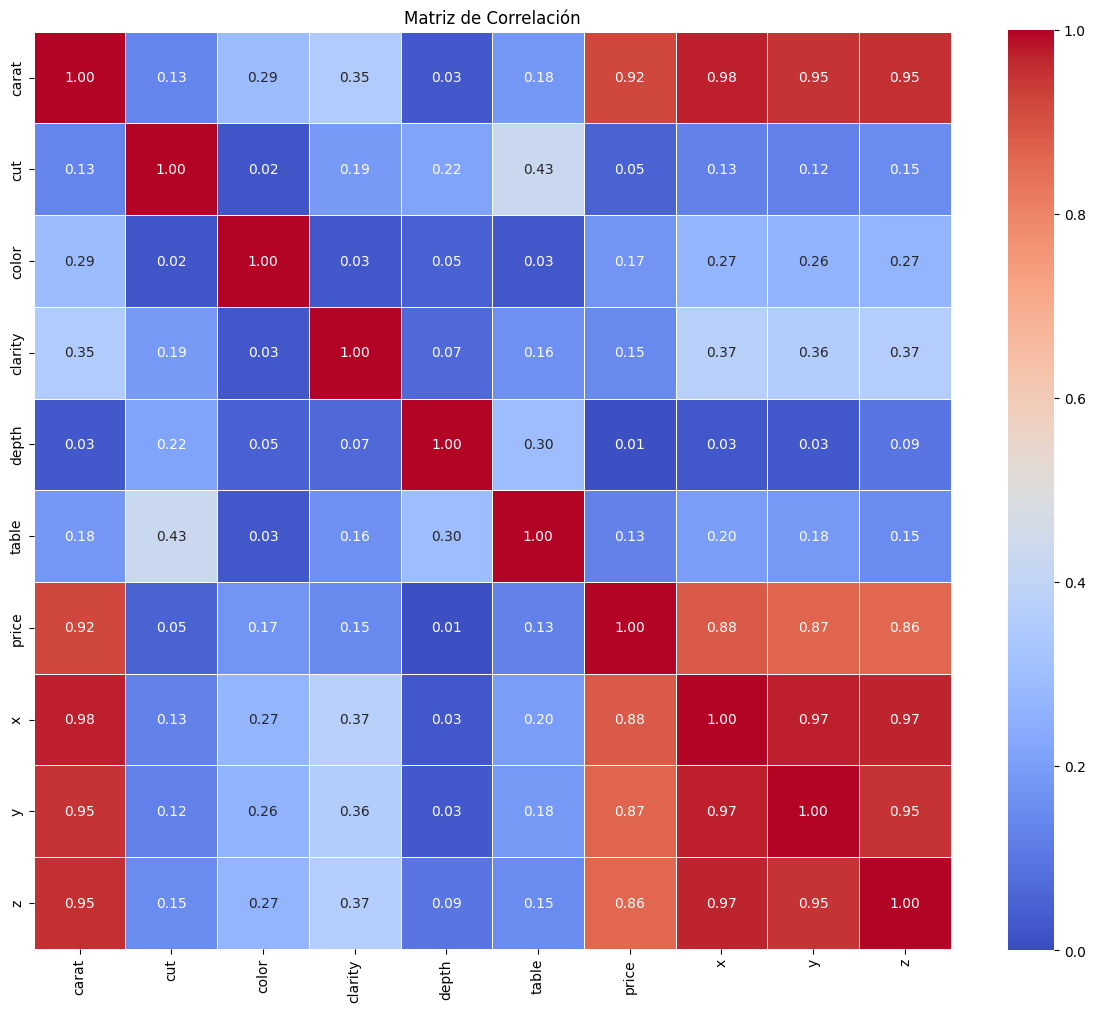

TODAS LAS CORRELACIONES CON PRICE (ordenadas):

carat      0.921591
x          0.884435
y          0.865421
z          0.861249
color      0.172511
clarity    0.146800
table      0.127134
cut        0.053491
depth      0.010647
Name: price, dtype: float64

TOP 5 CORRELACIONES CON PRICE

  1. carat: 0.9216
  2. x: 0.8844
  3. y: 0.8654
  4. z: 0.8612
  5. color: 0.1725


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1, square=True, linewidths=0.5)
plt.title('Matriz de Correlación')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print('TODAS LAS CORRELACIONES CON PRICE (ordenadas):\n')
correlaciones = corr['price'].sort_values(ascending=False).drop(index='price')
print(correlaciones)

print('\n' + '='*50)
print('TOP 5 CORRELACIONES CON PRICE\n')
for i, (col, val) in enumerate(correlaciones.head(5).items(), 1):
    print(f'  {i}. {col}: {val:.4f}')

### Método 2 - RFE (Recursive Feature Elimination)

In [8]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

X = df.drop(columns=['price'])
y = df['price']

rfe = RFE(estimator=LinearRegression(), n_features_to_select=5, step=1)
rfe.fit(X, y)

selected_features = X.columns[rfe.support_]
print('Características seleccionadas:', selected_features.tolist())

ranking = pd.Series(rfe.ranking_, index=X.columns).sort_values()
print('\n' + '='*50)
print('TOP 5 RFE (Ranking - 1=mejor):\n')
for i, (col, rank) in enumerate(ranking.head(5).items(), 1):
    print(f'  {i}. {col}: {rank}')

Características seleccionadas: ['carat', 'cut', 'color', 'clarity', 'x']

TOP 5 RFE (Ranking - 1=mejor):

  1. carat: 1
  2. cut: 1
  3. color: 1
  4. clarity: 1
  5. x: 1


### Método 3 - Feature Importance (Random Forest Integrado)

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('TODAS LAS IMPORTANCIAS (ordenadas):\n')
print(importancias)

print('\n' + '='*50)
print('TOP 5 FEATURE IMPORTANCE\n')
for i, (col, imp) in enumerate(importancias.head(5).items(), 1):
    print(f'  {i}. {col}: {imp:.4f}')

TODAS LAS IMPORTANCIAS (ordenadas):

carat      0.633023
y          0.255384
clarity    0.062990
color      0.031716
z          0.005044
x          0.004544
depth      0.003140
table      0.002335
cut        0.001824
dtype: float64

TOP 5 FEATURE IMPORTANCE

  1. carat: 0.6330
  2. y: 0.2554
  3. clarity: 0.0630
  4. color: 0.0317
  5. z: 0.0050


### Comparación Top 5 de los 3 métodos

In [10]:
print('='*60)
print('COMPARACIÓN TOP 5 - CORRELACIÓN vs RFE vs FEATURE IMPORTANCE')
print('='*60)

print('\n1. CORRELACIÓN (Valor absoluto):')
for i, (col, val) in enumerate(correlaciones.head(5).items(), 1):
    print(f'   {i}. {col}: {val:.4f}')

print('\n2. RFE (Ranking - 1=mejor):')
for i, (col, rank) in enumerate(ranking.head(5).items(), 1):
    print(f'   {i}. {col}: {rank}')

print('\n3. FEATURE IMPORTANCE (Random Forest):')
for i, (col, imp) in enumerate(importancias.head(5).items(), 1):
    print(f'   {i}. {col}: {imp:.4f}')

COMPARACIÓN TOP 5 - CORRELACIÓN vs RFE vs FEATURE IMPORTANCE

1. CORRELACIÓN (Valor absoluto):
   1. carat: 0.9216
   2. x: 0.8844
   3. y: 0.8654
   4. z: 0.8612
   5. color: 0.1725

2. RFE (Ranking - 1=mejor):
   1. carat: 1
   2. cut: 1
   3. color: 1
   4. clarity: 1
   5. x: 1

3. FEATURE IMPORTANCE (Random Forest):
   1. carat: 0.6330
   2. y: 0.2554
   3. clarity: 0.0630
   4. color: 0.0317
   5. z: 0.0050


## Paso 6 - Features seleccionadas
Se eligen las que aparecen consistentemente en los 3 métodos

In [11]:
columnas_modelo = ['carat', 'x', 'y', 'z', 'clarity', 'cut', 'color']

X = df[columnas_modelo]
y = df['price']

print(f'Features seleccionadas: {columnas_modelo}')
print(f'Shape X: {X.shape}')

Features seleccionadas: ['carat', 'x', 'y', 'z', 'clarity', 'cut', 'color']
Shape X: (53940, 7)


## Paso 7 - Escalado de variables con StandardScaler

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print('Escalado completado ✓')

Escalado completado ✓


## Paso 8 - Modelo de Regresión con KFold (K=7)
* Se usa RandomForestRegressor como modelo principal

* R2 (coeficiente de determinación): mide qué porcentaje de la variabilidad del precio explica el modelo. Va de 0 a 1 (puede ser negativo si el modelo es malo). Si R2 = 0.98, significa que el modelo explica el 98% de la variación del precio. Mientras más cerca de 1, mejor.
* MAE (Error Absoluto Medio): es el promedio de cuánto se equivoca el modelo en dólares, sin importar si predijo de más o de menos (usa valor absoluto). Si MAE = 287, significa que en promedio el modelo se equivoca por $287 al predecir el precio. Mientras más cerca de 0, mejor.

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error

modelo_principal = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)

# Validación cruzada con KFold (7 folds)
kf = KFold(n_splits=7, shuffle=True, random_state=42)

# Evaluamos R2 y MAE en cada fold - aqui se usa kf para dividir en 7 partes
r2_scores = cross_val_score(modelo_principal, X_scaled, y, cv=kf, scoring='r2')
mae_scores = cross_val_score(modelo_principal, X_scaled, y, cv=kf, scoring='neg_mean_absolute_error')
mae_scores = -mae_scores

# Si R2 sale negativo en alguna corrida o en el promedio, el modelo predice peor
# que simplemente usar el promedio de price (mal ajuste / alta varianza)
print('RandomForestRegressor (modelo principal)\n')
print(f"{'Corrida':<12} {'R2':<12} {'MAE'}")
print('-' * 35)
for i, (r2, mae) in enumerate(zip(r2_scores, mae_scores), 1):
    print(f'{i:<12} {r2:.4f}      {mae:.2f}')
print('-' * 35)
print(f"{'Promedio':<12} {r2_scores.mean():.4f}      {mae_scores.mean():.2f}")
print(f"{'Std':<12} {r2_scores.std():.4f}      {mae_scores.std():.2f}")

RandomForestRegressor (modelo principal)

Corrida      R2           MAE
-----------------------------------
1            0.9806      293.81
2            0.9800      291.44
3            0.9800      296.68
4            0.9794      299.42
5            0.9795      298.65
6            0.9803      293.78
7            0.9814      288.71
-----------------------------------
Promedio     0.9802      294.64
Std          0.0006      3.58


## Paso 9 - Una sola corrida para gráficas
Train/Test split para diagrama de dispersión y distribución de residuos

In [14]:
from sklearn.model_selection import train_test_split

# Para la evaluación final, entrenamos el modelo principal con un split tradicional (80% train, 20% test)
# una sola corrida, sin validación cruzada, para ver el desempeño final en un set de test independiente
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

modelo_principal.fit(X_train, y_train)
y_pred = modelo_principal.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Si R2 fuera negativo aquí, el modelo de esta corrida es peor que predecir el promedio
print(f'R2:  {r2:.4f}')
print(f'MAE: {mae:.2f}')

R2:  0.9801
MAE: 294.28


## Paso 10 - Diagrama de Dispersión
Valores reales vs valores predichos

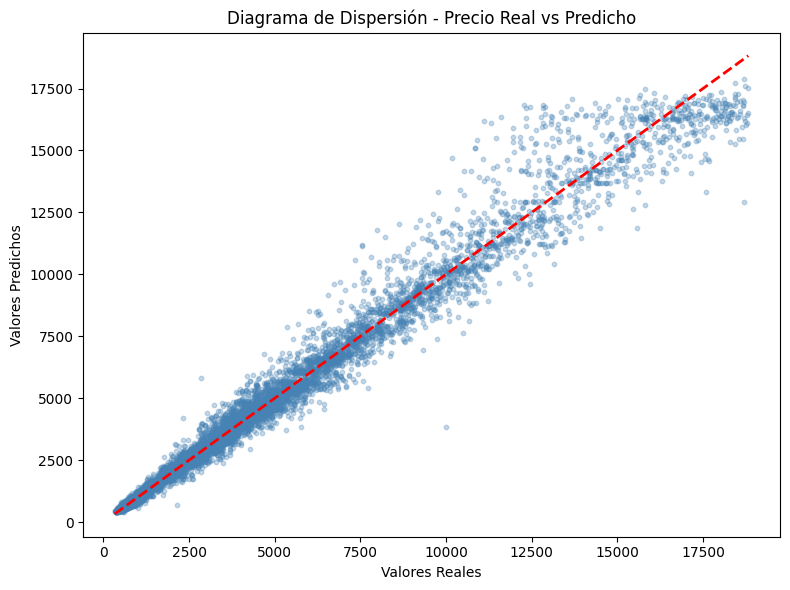

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Diagrama de Dispersión - Precio Real vs Predicho')
plt.tight_layout()
plt.show()

## Paso 11 - Distribución de Residuos
Debe ser normal y centrada en 0 para un buen modelo. 
Esto confirma que el modelo no tiene sesgo sistemático y comete errores pequeños la mayoría de las veces.

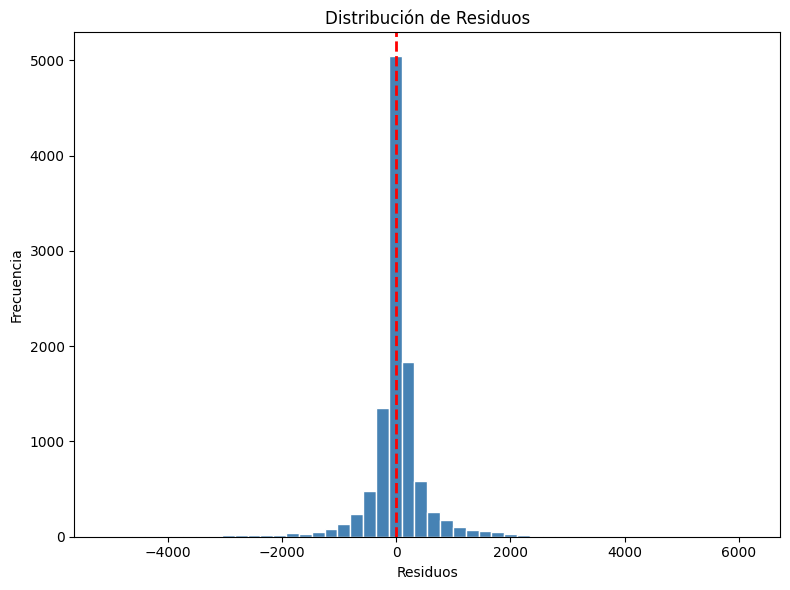

Media de residuos: -9.79 (ideal: 0)
Std de residuos:   562.52


In [16]:
residuos = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.hist(residuos, bins=50, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Distribución de Residuos')
plt.tight_layout()
plt.show()

print(f'Media de residuos: {residuos.mean():.2f} (ideal: 0)')
print(f'Std de residuos:   {residuos.std():.2f}')

## Paso 12 - Exportar el modelo

In [17]:
import joblib

joblib.dump(modelo_principal, 'modelo_diamonds.pkl')
joblib.dump(scaler, 'scaler_diamonds.pkl')

['scaler_diamonds.pkl']